# 🛢️ Well Log Prediction — Beginner Practical Session
## Predicting DTC (Compressional Slowness) from Conventional Logs
---
**Wells:** 35/11-1 · 35/11-5 · 35/11-6 (training) | 35/11-7 (blind test)

**Target:** DT — Compressional sonic slowness (µs/ft)

**Features:** GR · RHOB · NPHI · PEF · RDEP

---
### Workflow
1. Load LAS files
2. Clean data
3. Visualize (histogram · boxplot · heatmap · pairplot · log tracks)
4. Scale features
5. Split train / validation / blind
6. Compare models (LazyPredict style)
7. Detailed training with best model
8. Blind well prediction & evaluation


---
## 📦 STEP 1 — Install Libraries



In [7]:
pip install lasio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.0 MB/s eta 0:00:00


---
## 📦 STEP 2 — Import Libraries
We import everything we need upfront. Each library has a specific role:
- **pandas / numpy** → data handling and math
- **matplotlib / seaborn** → plotting
- **sklearn** → machine learning models and tools


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [183]:
# ── Core data libraries ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import lasio

# ── Plotting ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── ML: preprocessing ────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── ML: regression models ────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

# ── ML: evaluation metrics ───────────────────────────────────────────────
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── Settings ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('All libraries imported successfully!')


All libraries imported successfully!


---
## 📂 STEP 3 — LAS File Reader
LAS (Log ASCII Standard) is the standard format for well log data.
The null value in these files is **-999.25** — we replace it with NaN.


---
## 📂 STEP 4 — Load the Wells
We load all 4 wells and tag each row with the well name.
Well **35/11-7** is the **blind well** — kept separate for final testing.


In [28]:
# in case of Las files

# # Define the folder path where your LAS files are located
# # If they are in the same folder as this notebook, we can use '.'
# path = '/content/drive/MyDrive/SPE'

# # List of the 4 well filenames provided
# well_files = ['35_11-1.las', '35_11-5.las', '35_11-6.las', '35_11-7.las']

# # Create an empty dictionary to store the data from each well, indexed by well name
# wells = {}

# # Loop through each file in our list
# for well_file in well_files:
#     # Construct the full file path
#     full_path = os.path.join(path, well_file)

#     # Read the LAS file using lasio
#     las = lasio.read(full_path)

#     # Convert the curves (logs) into a Pandas DataFrame
#     df = las.df()

#     # Get the well name from the filename (e.g., '35_11-1.las' -> '35/11-1')
#     well_name_raw = well_file.replace('_', '/')
#     well_name = well_name_raw.split('.')[0]

#     # Add a column for the well name to identify the data later
#     df['WELL'] = well_name

#     # Depth is usually the index in lasio, let's make it a regular column
#     df = df.reset_index()

#     # Store this well's dataframe in the 'wells' dictionary
#     wells[well_name] = df
#     print(f'Well {well_name}: {df.shape[0]:,} rows | curves: {list(df.columns[:10])}')

# print('\nAll wells loaded!')

In [123]:
# Load the dataset
df_raw = pd.read_csv('/content/drive/MyDrive/SPE/Wells.csv')

# Look at the first 5 rows to see what we have
df_raw.head(5)

,index,DEPTH,DT,GR,NPHI,PEF,RHOB,WELL
0,0,188.5,NaN,4.300,NaN,NaN,NaN,15/9-F-11 B
1,1,188.6,NaN,3.801,NaN,NaN,NaN,15/9-F-11 B
2,2,188.7,NaN,4.301,NaN,NaN,NaN,15/9-F-11 B
3,3,188.8,NaN,4.600,NaN,NaN,NaN,15/9-F-11 B
4,4,188.9,NaN,4.599,NaN,NaN,NaN,15/9-F-11 B


In [124]:
# Display 10 random rows from the dataframe
# 'n=10' tells pandas exactly how many rows to pick
random_rows = df_raw.sample(n=10)

# Show the result
random_rows

,index,DEPTH,DT,GR,NPHI,PEF,RHOB,WELL
5741,5741,762.6,NaN,65.2300,NaN,NaN,NaN,15/9-F-11 B
30809,30809,3269.4,NaN,24.6310,0.0860,7.2520,2.6090,15/9-F-11 B
102406,141887,2231.2,NaN,96.1374,NaN,NaN,NaN,15/9-F-1 B
69436,69436,2550.3,NaN,61.5560,NaN,NaN,NaN,15/9-F-11 A
141665,181146,2838.0,69.6468,3.3694,0.1349,7.8825,2.4661,15/9-F-1 A
131107,170588,1782.2,NaN,88.9284,NaN,NaN,NaN,15/9-F-1 A
103785,143266,2369.1,NaN,73.2523,NaN,NaN,NaN,15/9-F-1 B
52047,52047,811.4,NaN,66.7850,NaN,NaN,NaN,15/9-F-11 A
89187,128668,909.3,NaN,32.5021,NaN,NaN,NaN,15/9-F-1 B
15321,15321,1720.6,NaN,86.2960,NaN,NaN,NaN,15/9-F-11 B


In [125]:
df_raw.columns

Index(['index', 'DEPTH', 'DT', 'GR', 'NPHI', 'PEF', 'RHOB', 'WELL'], dtype='object')

In [126]:
df_raw.shape

(150105, 8)

In [127]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150105 entries, 0 to 150104
Data columns (total 8 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   index   150105 non-null  int64  
 1   DEPTH   150105 non-null  float64
 2   DT      25961 non-null   float64
 3   GR      148431 non-null  float64
 4   NPHI    41000 non-null   float64
 5   PEF     41109 non-null   float64
 6   RHOB    41109 non-null   float64
 7   WELL    150105 non-null  object 
dtypes: float64(6), int64(1), object(1)
memory usage: 9.2+ MB


In [128]:
df_raw['WELL'].unique().tolist()

['15/9-F-11 B', '15/9-F-11 A', '15/9-F-1 B', '15/9-F-1 A']

---
## 🧹 STEP 5 — Data Cleaning
**Steps:**
1. Select only the logs we need (features + target)
2. Drop rows where any column is NaN
3. Apply physical range filters to remove bad data points


In [129]:
# ── Define which logs to use ─────────────────────────────────────────────
FEATURES = ['RHOB', 'GR', 'NPHI', 'PEF']   # input logs
TARGET   = 'DT'                                      # log to predict
COLS     = ['DEPTH'] + FEATURES + [TARGET, 'WELL'] # Include DEPT in the columns


print('\nMissing values per column:')
print(df_raw[FEATURES + [TARGET]].isnull().sum())


Missing values per column:
RHOB    108996
GR        1674
NPHI    109105
PEF     108996
DT      124144
dtype: int64


In [130]:
# Training Wells
training_wells = ['15/9-F-11 B', '15/9-F-11 A', '15/9-F-1 A']

# Test Well
test_well = ['15/9-F-1 B']

In [144]:
df_train_raw = df_raw[df_raw['WELL'].isin(training_wells)].copy()
df_blind_raw = df_raw[df_raw['WELL'].isin(test_well)].copy()


In [145]:
print("The Wells used in Model Training are:",df_train_raw['WELL'].unique().tolist())
print("The Wells used in Model Validation are:" , df_blind_raw['WELL'].unique().tolist())

The Wells used in Model Training are: ['15/9-F-11 B', '15/9-F-11 A', '15/9-F-1 A']
The Wells used in Model Validation are: ['15/9-F-1 B']


In [147]:
df_train_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 116914 entries, 0 to 150104
Data columns (total 8 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   index   116914 non-null  int64  
 1   DEPTH   116914 non-null  float64
 2   DT      21699 non-null   float64
 3   GR      115933 non-null  float64
 4   NPHI    37587 non-null   float64
 5   PEF     37668 non-null   float64
 6   RHOB    37668 non-null   float64
 7   WELL    116914 non-null  object 
dtypes: float64(6), int64(1), object(1)
memory usage: 8.0+ MB


In [168]:
# ── Drop rows with NaN in any of our key columns ─────────────────────────
df_train = df_train_raw.dropna(subset=FEATURES + [TARGET])
print(f'After NaN removal: {len(df_train):,} rows')

# ── Apply physical range filters ─────────────────────────────────────────
# These ranges come from petrophysical knowledge of typical log responses

df_train = df_train[(df_train['GR']   >=   0) & (df_train['GR']   <= 200)]  # gAPI
df_train = df_train[(df_train['RHOB'] >= 1.5) & (df_train['RHOB'] <= 3.0)]  # g/cc
df_train = df_train[(df_train['NPHI'] >=-0.1) & (df_train['NPHI'] <= 1.0)]  # v/v
df_train = df_train[(df_train['PEF']  >=   0) & (df_train['PEF']  <=  10)]  # b/e
df_train = df_train[(df_train['DT']  >=  40) & (df_train['DT']  <= 200)]  # us/ft

df_train = df_train.reset_index(drop=True)
print(f'After range filter: {len(df_train):,} rows')
print('\nRows per well:')
print(df_train['WELL'].value_counts())


After NaN removal: 21,688 rows
After range filter: 20,840 rows

Rows per well:
WELL
15/9-F-11 A    11171
15/9-F-1 A      9669
Name: count, dtype: int64


In [169]:
df_train['WELL'].unique().tolist()

['15/9-F-11 A', '15/9-F-1 A']

In [ ]:
#The remain training Wells are only 2 wells from Total 3, because the recoreded lo intervals no overlapped in The well '15/9-F-11 B'

In [170]:
# ── Clean the blind well the same way ────────────────────────────────────
df_blind = df_blind_raw.dropna(subset=FEATURES + [TARGET])
print(f'After NaN removal: {len(df_train):,} rows')

df_blind = df_blind_raw.dropna(subset=FEATURES + [TARGET])
df_blind = df_blind[(df_blind['GR']   >=   0) & (df_blind['GR']   <= 200)]
df_blind = df_blind[(df_blind['RHOB'] >= 1.5) & (df_blind['RHOB'] <= 3.0)]
df_blind = df_blind[(df_blind['NPHI'] >=-0.1) & (df_blind['NPHI'] <= 1.0)]
df_blind = df_blind[(df_blind['PEF']  >=   0) & (df_blind['PEF']  <=  10)]
df_blind = df_blind[(df_blind['DT']  >=  40) & (df_blind['DT']  <= 200)]
df_blind = df_blind.reset_index(drop=True)

print(f'Blind well (15/9-F-1 B) clean rows: {len(df_blind):,}')
display(df_blind[FEATURES + [TARGET]].describe().round(2))

After NaN removal: 20,840 rows
Blind well (15/9-F-1 B) clean rows: 2,982


,RHOB,GR,NPHI,PEF,DT
count,2982.00,2982.00,2982.00,2982.00,2982.00
mean,2.47,56.99,0.18,6.38,81.05
std,0.12,35.31,0.07,0.79,10.02
min,2.15,8.00,0.06,4.73,58.63
25%,2.43,37.21,0.14,5.87,74.13
50%,2.49,49.07,0.17,6.29,79.43
75%,2.54,59.55,0.20,6.79,85.82
max,2.96,199.47,0.47,9.90,122.90


---
## 📊 STEP 6 — Exploratory Data Visualization
We explore the data before modeling:
- **Histograms** — value distributions
- **Boxplots** — outliers per well
- **Correlation heatmap** — which logs relate to DTC
- **Pairplot** — all relationships at once
- **Log tracks** — classic petrophysical display


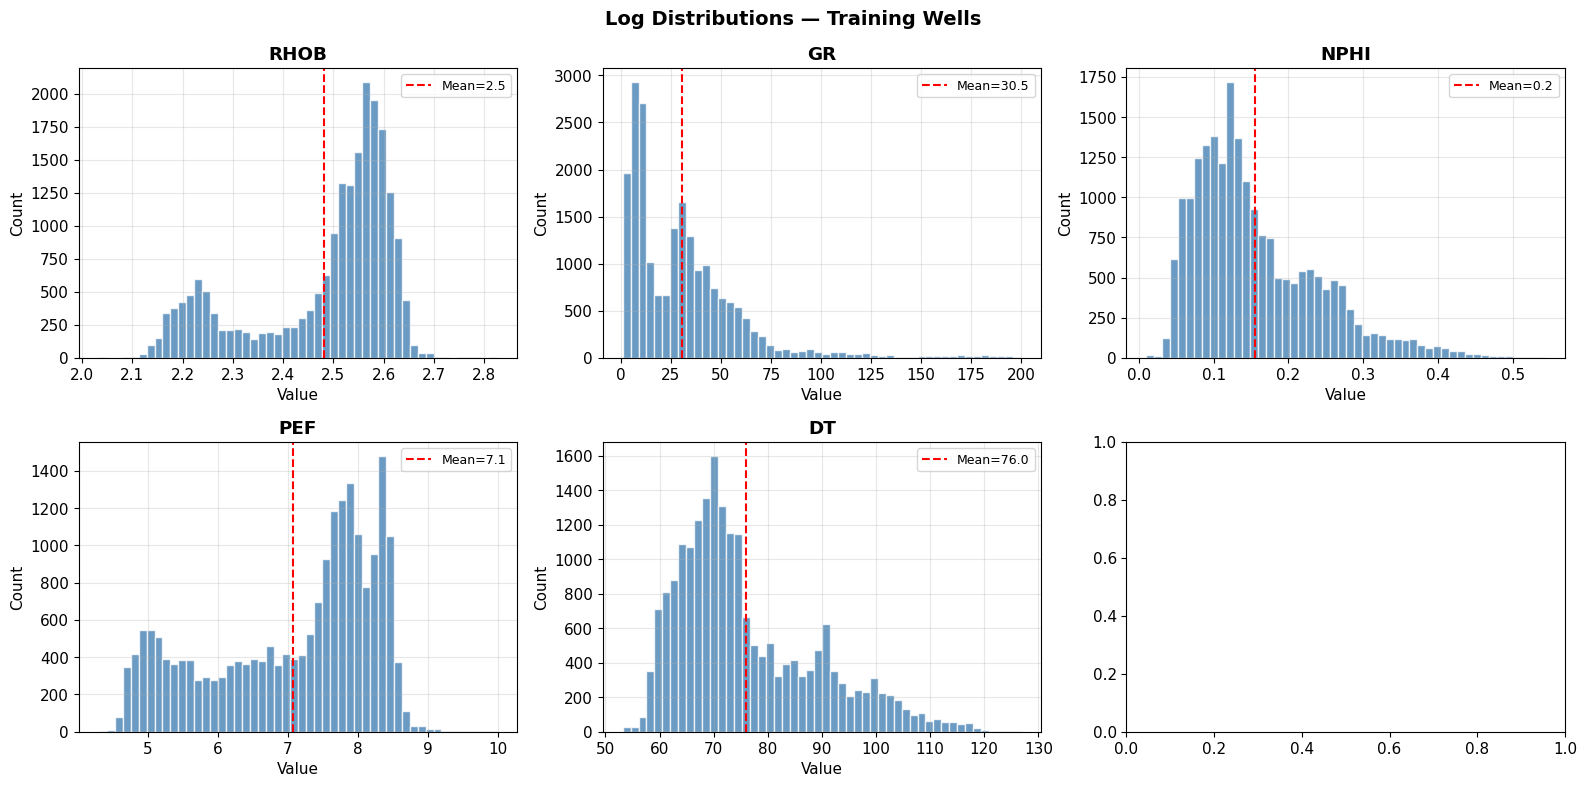

In [171]:
# ── 6.1 Histograms ───────────────────────────────────────────────────────
all_logs = FEATURES + [TARGET]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Log Distributions — Training Wells', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(all_logs):
    data = df_train[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Mean={data.mean():.1f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


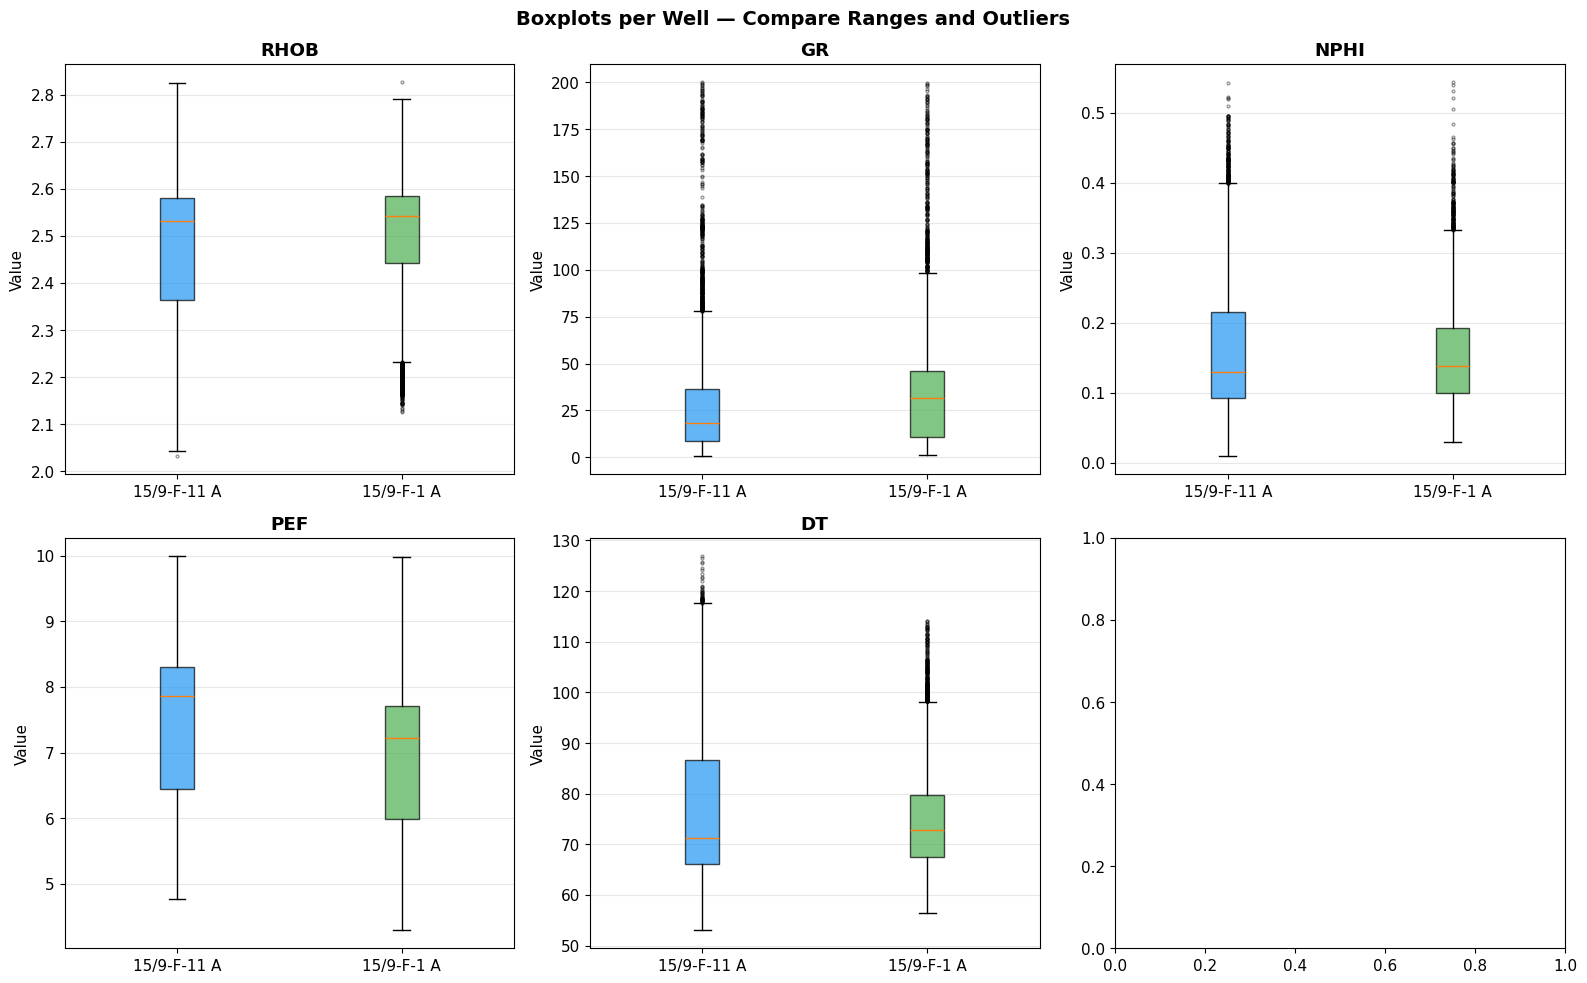

In [172]:
# ── 6.2 Boxplots per well ────────────────────────────────────────────────
# Dots outside the whiskers = outliers

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Boxplots per Well — Compare Ranges and Outliers', fontsize=14, fontweight='bold')
axes = axes.flatten()

well_colors = {'15/9-F-11 A': '#2196F3', '15/9-F-1 A': '#4CAF50'}

for i, col in enumerate(all_logs):
    ax = axes[i]
    data_per_well = []
    labels = []
    for wname in ['15/9-F-11 A', '15/9-F-1 A']:
        data_per_well.append(df_train[df_train['WELL'] == wname][col].dropna().values)
        labels.append(wname)

    bp = ax.boxplot(data_per_well, labels=labels, patch_artist=True,
                    flierprops=dict(marker='o', markersize=2, alpha=0.4))
    for patch, wname in zip(bp['boxes'], ['15/9-F-11 A', '15/9-F-1 A']):
        patch.set_facecolor(well_colors[wname])
        patch.set_alpha(0.7)

    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


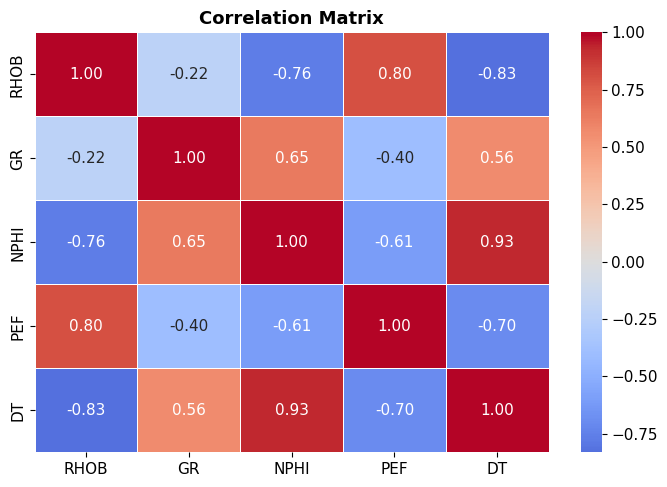

Correlation with DT (target):
NPHI    0.929
GR      0.565
PEF    -0.695
RHOB   -0.830
Name: DT, dtype: float64


In [173]:
# ── 6.3 Correlation Heatmap ───────────────────────────────────────────────
# Values close to +1 or -1 with DT = strong predictor

corr = df_train[all_logs].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation with DT (target):')
print(corr['DT'].drop('DT').sort_values(ascending=False).round(3))


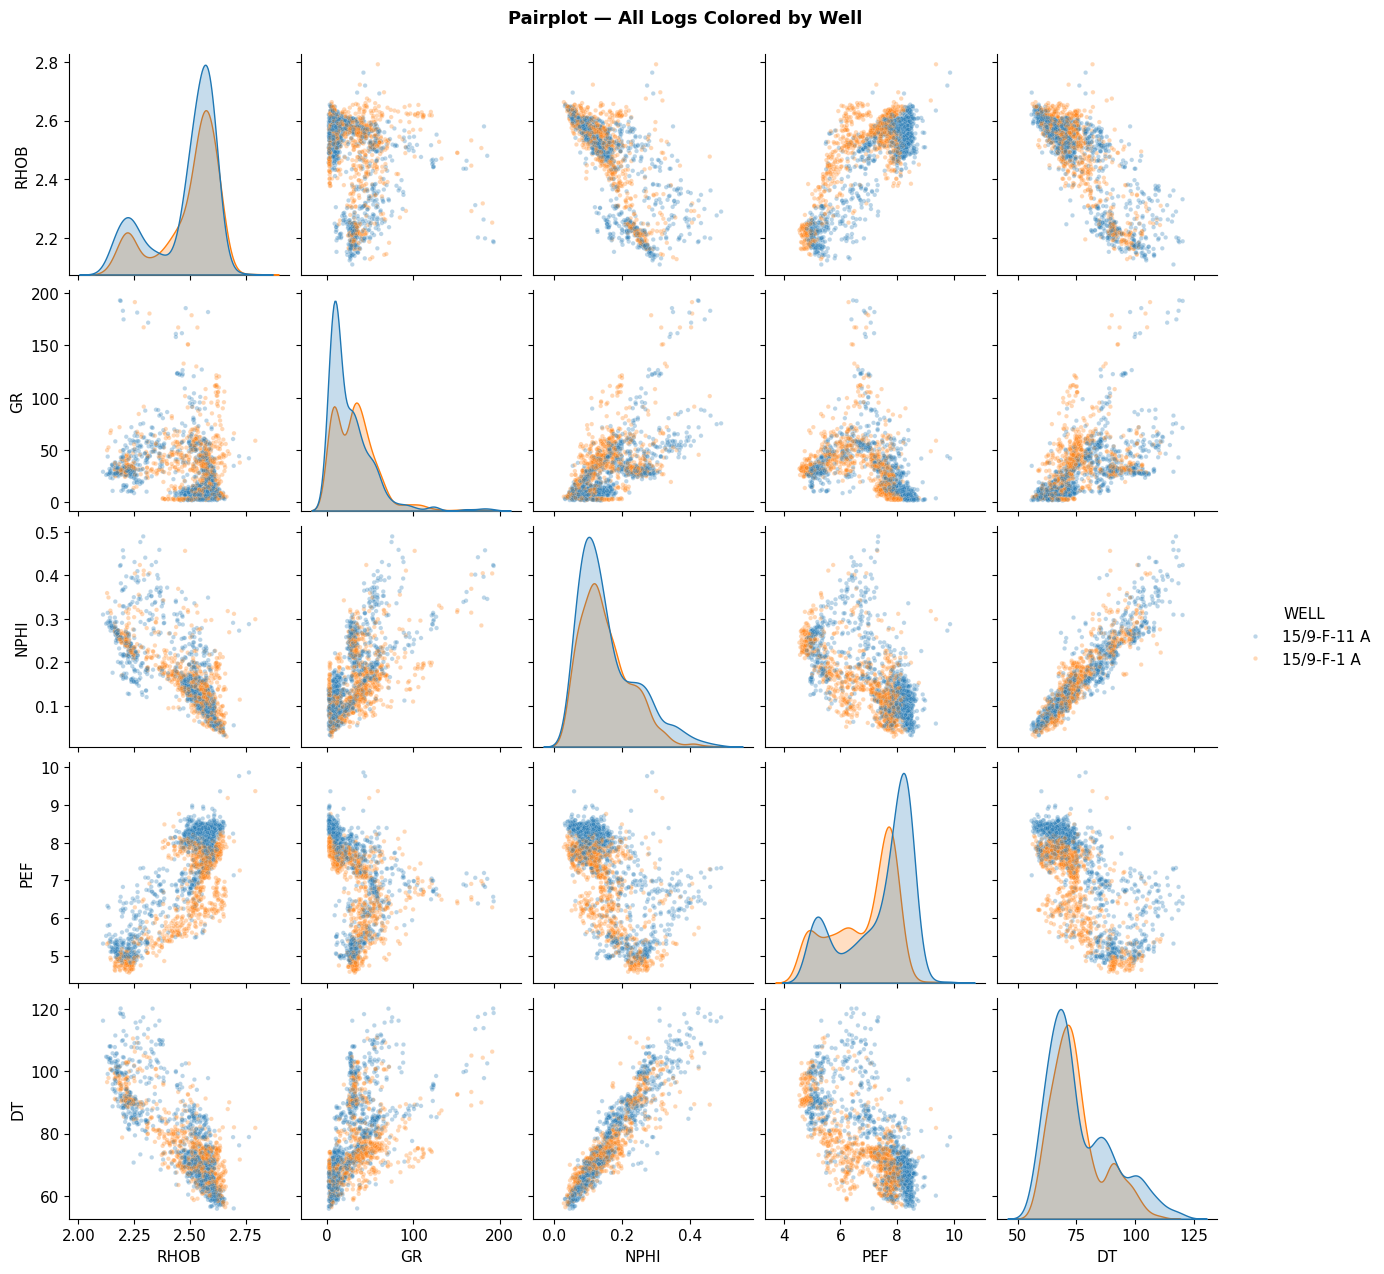

In [174]:
# ── 6.4 Pairplot ─────────────────────────────────────────────────────────
# Shows scatter plot for every pair of logs — colored by well
# We sample 2000 rows to keep it fast

df_sample = df_train[all_logs + ['WELL']].sample(n=2000, random_state=42)

pg = sns.pairplot(df_sample, hue='WELL', vars=all_logs,
                  diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
pg.figure.suptitle('Pairplot — All Logs Colored by Well', y=1.02,
                    fontsize=13, fontweight='bold')
plt.show()


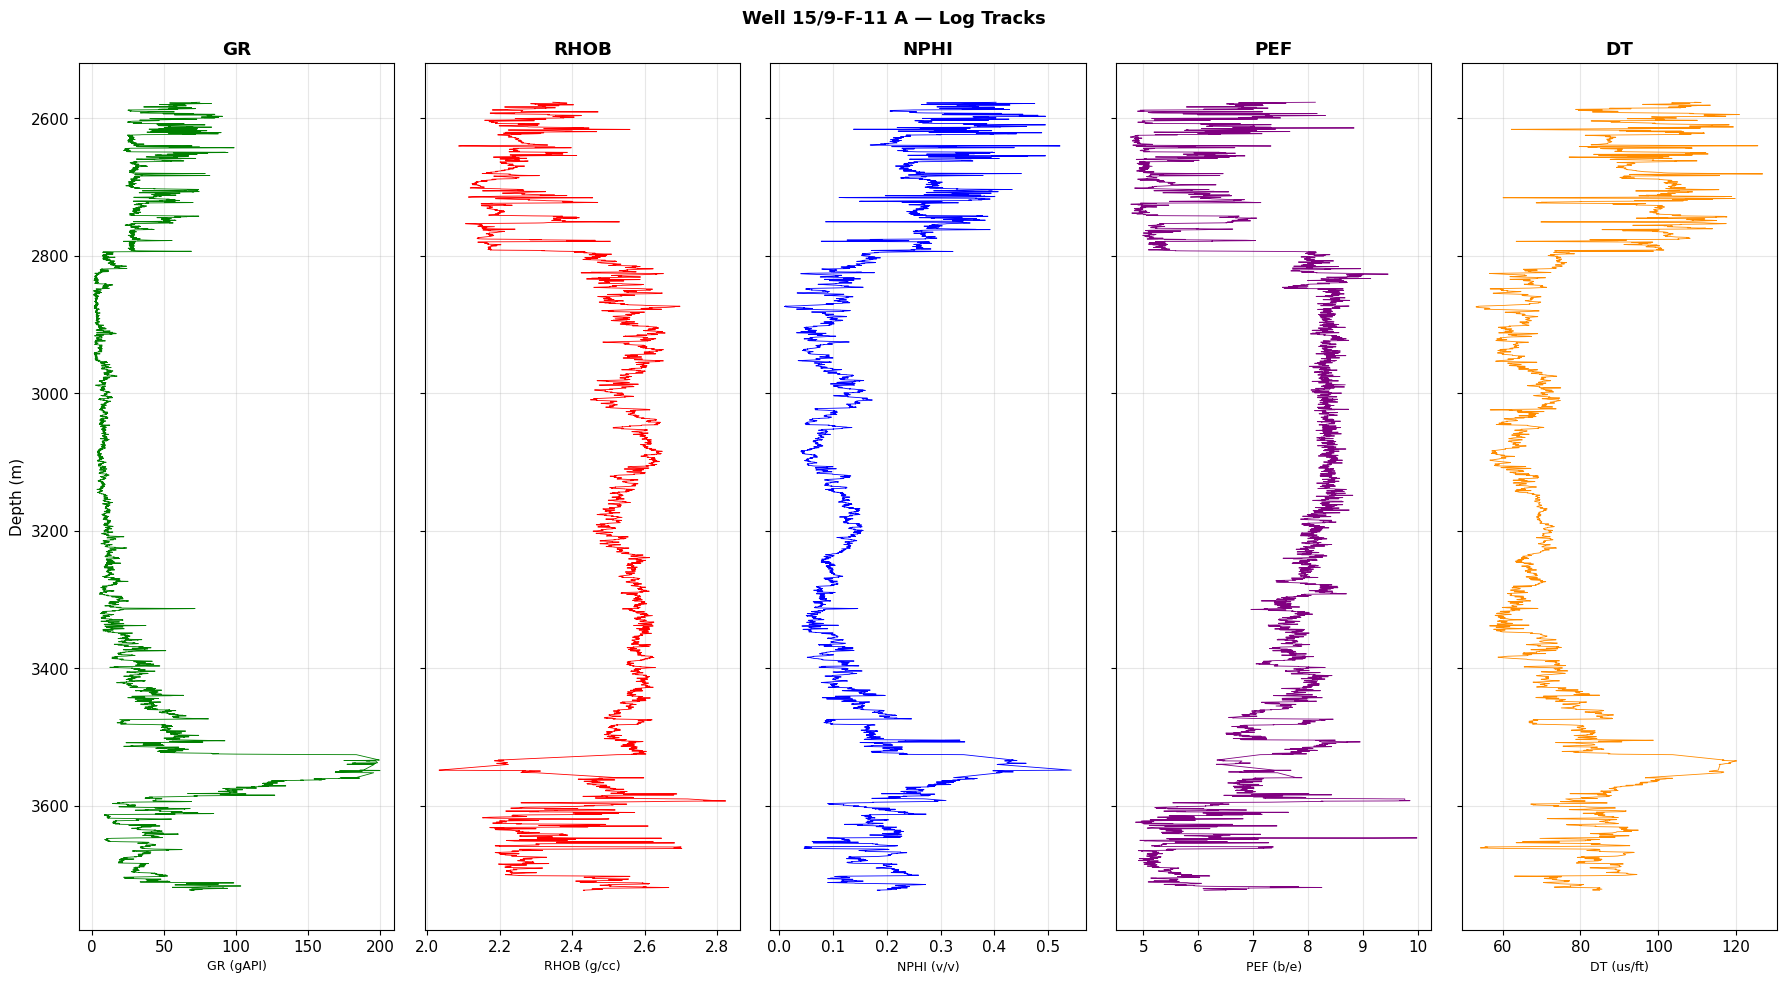

In [176]:
# ── 6.5 Log Track Display ────────────────────────────────────────────────
# Classic well log view: depth on Y-axis (increasing downward)

df_plot = df_train[df_train['WELL'] == '15/9-F-11 A'].copy()
depth   = df_plot['DEPTH']

tracks = [
    ('GR',   'green',      'GR (gAPI)'),
    ('RHOB', 'red',        'RHOB (g/cc)'),
    ('NPHI', 'blue',       'NPHI (v/v)'),
    ('PEF',  'purple',     'PEF (b/e)'),
    ('DT',  'darkorange', 'DT (us/ft)'),
]

fig, axes = plt.subplots(1, 5, figsize=(18, 10), sharey=True)
fig.suptitle('Well 15/9-F-11 A — Log Tracks', fontsize=13, fontweight='bold')

for ax, (log, color, label) in zip(axes, tracks):
    ax.plot(df_plot[log], depth, color=color, linewidth=0.6)
    ax.set_xlabel(label, fontsize=9)
    ax.set_title(log, fontweight='bold')
    ax.invert_yaxis()    # depth increases downward
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Depth (m)', fontsize=11)
plt.tight_layout()
plt.show()


---
## ⚖️ STEP 7 — Feature Scaling
Different logs have very different ranges (GR: 0–300 vs RHOB: 1.5–3.0).
Scaling brings them all to the same scale: **mean=0, std=1**.

**Rule:** Fit the scaler on training data ONLY, then apply to blind well.


In [177]:
# ── Extract arrays ───────────────────────────────────────────────────────
X_train_full = df_train[FEATURES].values   # features matrix
y_train_full = df_train[TARGET].values     # target vector

X_blind = df_blind[FEATURES].values
y_blind = df_blind[TARGET].values

print(f'Training set shape : {X_train_full.shape}')
print(f'Blind well shape   : {X_blind.shape}')

# ── Fit scaler on training data only ─────────────────────────────────────
scaler = StandardScaler()
scaler.fit(X_train_full)                        # learn mean and std from training data

X_train_scaled = scaler.transform(X_train_full) # apply to training data
X_blind_scaled = scaler.transform(X_blind)      # apply SAME scaler to blind well

# Verify: mean should be ~0 and std should be ~1 after scaling
print('\nAfter scaling — means (should be ~0):')
print(dict(zip(FEATURES, X_train_scaled.mean(axis=0).round(4))))
print('\nAfter scaling — stds (should be ~1):')
print(dict(zip(FEATURES, X_train_scaled.std(axis=0).round(4))))


Training set shape : (20840, 4)
Blind well shape   : (2982, 4)

After scaling — means (should be ~0):
{'RHOB': np.float64(0.0), 'GR': np.float64(0.0), 'NPHI': np.float64(-0.0), 'PEF': np.float64(0.0)}

After scaling — stds (should be ~1):
{'RHOB': np.float64(1.0), 'GR': np.float64(1.0), 'NPHI': np.float64(1.0), 'PEF': np.float64(1.0)}


---
## ✂️ STEP 8 — Train / Validation Split
We split the training wells data into **80% train** and **20% validation**.
The blind well (35/11-7) stays completely untouched until the final step.


In [178]:
# ── 80% train / 20% validation split ────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_train_scaled,
    y_train_full,
    test_size=0.2,
    random_state=42
)

print(f'Train      : {X_train.shape[0]:,} rows')
print(f'Validation : {X_val.shape[0]:,} rows')
print(f'Blind well : {X_blind_scaled.shape[0]:,} rows  <-- never seen by model')


Train      : 16,672 rows
Validation : 4,168 rows
Blind well : 2,982 rows  <-- never seen by model


---
## 🏃 STEP 9 — Model Comparison (LazyPredict Style)
We train **9 models** and rank them by performance on the validation set.

**Metrics:**
- **R²** — proportion of variance explained (1.0 = perfect)
- **MAE** — mean absolute error in µs/ft (lower = better)
- **RMSE** — root mean square error in µs/ft (lower = better)


In [181]:
# ── Define all models ────────────────────────────────────────────────────

models_to_test = [
    ('Linear Regression',   LinearRegression()),
    ('Ridge',               Ridge()),
    ('Lasso',               Lasso()),
    ('K-Nearest Neighbors', KNeighborsRegressor(n_neighbors=5)),
    ('Decision Tree',       DecisionTreeRegressor(random_state=42)),
    ('Random Forest',       RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgboost',             XGBRegressor(n_estimators=100, random_state=42)), # Corrected class name
    ('Neural Network',      MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=500,
                                         random_state=42, early_stopping=True)),
]

# ── Train each model and record results ──────────────────────────────────
results = []

for model_name, model in models_to_test:
    print(f'Training: {model_name}...', end=' ')

    model.fit(X_train, y_train)           # train
    y_pred_val = model.predict(X_val)     # predict on validation set

    r2   = r2_score(y_val, y_pred_val)
    mae  = mean_absolute_error(y_val, y_pred_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))

    results.append({'Model': model_name, 'R2': round(r2, 4),
                    'MAE': round(mae, 3), 'RMSE': round(rmse, 3),
                    'object': model})

    print(f'R2={r2:.4f}  MAE={mae:.2f}  RMSE={rmse:.2f}')

print('\nAll models trained!')

Training: Linear Regression... R2=0.9040  MAE=2.78  RMSE=3.95
Training: Ridge... R2=0.9040  MAE=2.78  RMSE=3.95
Training: Lasso... R2=0.8943  MAE=3.05  RMSE=4.15
Training: K-Nearest Neighbors... R2=0.9531  MAE=1.51  RMSE=2.77
Training: Decision Tree... R2=0.9030  MAE=2.00  RMSE=3.98
Training: Random Forest... R2=0.9502  MAE=1.58  RMSE=2.85
Training: xgboost... R2=0.9453  MAE=1.77  RMSE=2.99
Training: Neural Network... R2=0.9306  MAE=2.12  RMSE=3.36

All models trained!


In [184]:
# ── Show ranked results table ─────────────────────────────────────────────
results_df = pd.DataFrame(results).drop(columns=['object'])
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
results_df.index += 1

print('MODEL COMPARISON — Ranked by R2 (Validation Set)')
display(results_df)

best_model_name = results_df.iloc[0]['Model']
print(f'\nBest model: {best_model_name}')


MODEL COMPARISON — Ranked by R2 (Validation Set)


,Model,R2,MAE,RMSE
1,K-Nearest Neighbors,0.9531,1.507,2.765
2,Random Forest,0.9502,1.577,2.849
3,xgboost,0.9453,1.772,2.985
4,Neural Network,0.9306,2.122,3.362
5,Linear Regression,0.9040,2.780,3.954
6,Ridge,0.9040,2.780,3.954
7,Decision Tree,0.9030,1.995,3.975
8,Lasso,0.8943,3.051,4.150



Best model: K-Nearest Neighbors


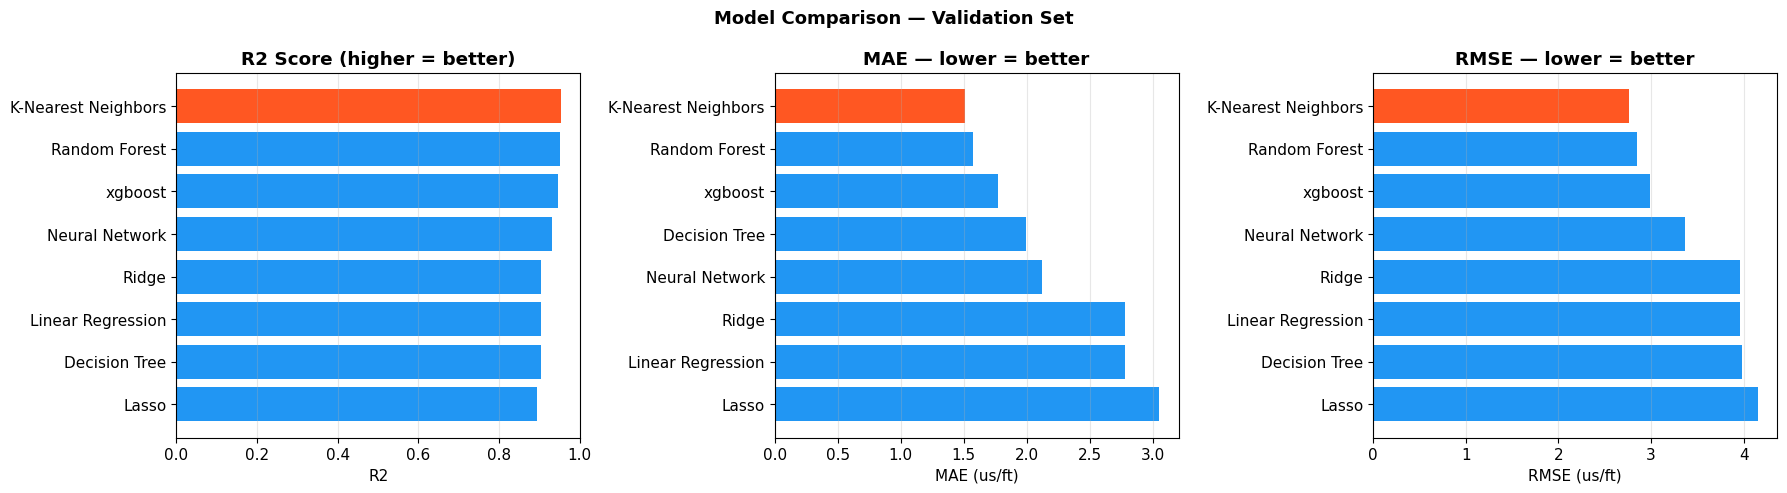

Red bar = K-Nearest Neighbors (best model)


In [185]:
# ── Bar chart comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Comparison — Validation Set', fontsize=13, fontweight='bold')

plot_df = results_df.sort_values('R2', ascending=True)
colors  = ['#FF5722' if n == best_model_name else '#2196F3' for n in plot_df['Model']]

axes[0].barh(plot_df['Model'], plot_df['R2'], color=colors)
axes[0].set_title('R2 Score (higher = better)', fontweight='bold')
axes[0].set_xlabel('R2')
axes[0].grid(True, axis='x', alpha=0.3)

plot_df2 = results_df.sort_values('MAE', ascending=False)
colors2  = ['#FF5722' if n == best_model_name else '#2196F3' for n in plot_df2['Model']]
axes[1].barh(plot_df2['Model'], plot_df2['MAE'], color=colors2)
axes[1].set_title('MAE — lower = better', fontweight='bold')
axes[1].set_xlabel('MAE (us/ft)')
axes[1].grid(True, axis='x', alpha=0.3)

plot_df3 = results_df.sort_values('RMSE', ascending=False)
colors3  = ['#FF5722' if n == best_model_name else '#2196F3' for n in plot_df3['Model']]
axes[2].barh(plot_df3['Model'], plot_df3['RMSE'], color=colors3)
axes[2].set_title('RMSE — lower = better', fontweight='bold')
axes[2].set_xlabel('RMSE (us/ft)')
axes[2].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Red bar = {best_model_name} (best model)')


---
## 🔬 STEP 10 — Detailed Training with Best Model
We retrain the best model on **all training data** (train + validation combined)
then examine feature importance and scatter plot.


In [186]:
# ── Retrieve the best model object ───────────────────────────────────────
best_model = None
for entry in results:
    if entry['Model'] == best_model_name:
        best_model = entry['object']
        break

# ── Retrain on full training data (train + val combined) ──────────────────
X_all = np.vstack([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

print(f'Retraining {best_model_name} on {len(X_all):,} samples...')
best_model.fit(X_all, y_all)
print('Done!')


Retraining K-Nearest Neighbors on 20,840 samples...
Done!


In [187]:
# ── Feature Importance (tree-based models only) ───────────────────────────
if hasattr(best_model, 'feature_importances_'):
    imp_df = pd.DataFrame({'Feature': FEATURES,
                            'Importance': best_model.feature_importances_})
    imp_df = imp_df.sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue')
    ax.set_title(f'Feature Importance — {best_model_name}', fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_model_name} does not have feature_importances_')
    print('Feature importance is available for: Random Forest, Extra Trees, Gradient Boosting, Decision Tree')


K-Nearest Neighbors does not have feature_importances_
Feature importance is available for: Random Forest, Extra Trees, Gradient Boosting, Decision Tree


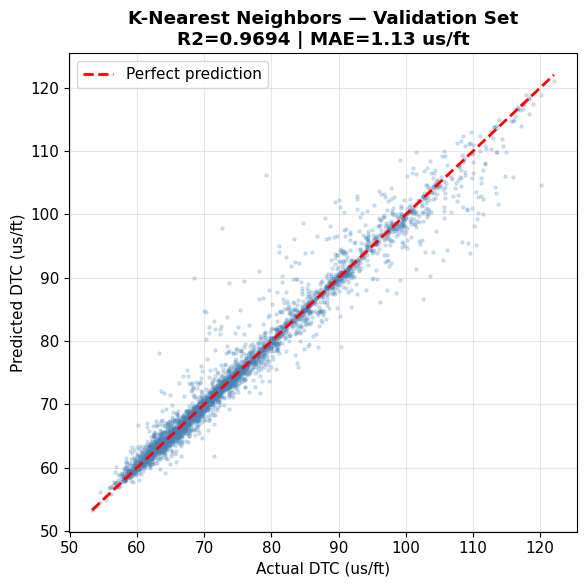

In [188]:
# ── Predicted vs Actual scatter — Validation Set ──────────────────────────
y_val_pred = best_model.predict(X_val)
r2_v  = r2_score(y_val, y_val_pred)
mae_v = mean_absolute_error(y_val, y_val_pred)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_val, y_val_pred, alpha=0.2, s=5, color='steelblue')
mn, mx = y_val.min(), y_val.max()
ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual DTC (us/ft)')
ax.set_ylabel('Predicted DTC (us/ft)')
ax.set_title(f'{best_model_name} — Validation Set\nR2={r2_v:.4f} | MAE={mae_v:.2f} us/ft',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 🧪 STEP 11 — Blind Well Prediction & Final Evaluation
The ultimate test — predicting DTC on **well 35/11-7** which the model has never seen.


In [189]:
# ── Predict on blind well ────────────────────────────────────────────────
y_blind_pred = best_model.predict(X_blind_scaled)

r2_b   = r2_score(y_blind, y_blind_pred)
mae_b  = mean_absolute_error(y_blind, y_blind_pred)
rmse_b = np.sqrt(mean_squared_error(y_blind, y_blind_pred))

print('=' * 50)
print(f'  BLIND WELL (35/11-7) — Final Results')
print('=' * 50)
print(f'  Model : {best_model_name}')
print(f'  R2    : {r2_b:.4f}')
print(f'  MAE   : {mae_b:.2f} us/ft')
print(f'  RMSE  : {rmse_b:.2f} us/ft')
print('=' * 50)


  BLIND WELL (35/11-7) — Final Results
  Model : K-Nearest Neighbors
  R2    : 0.7437
  MAE   : 3.84 us/ft
  RMSE  : 5.07 us/ft


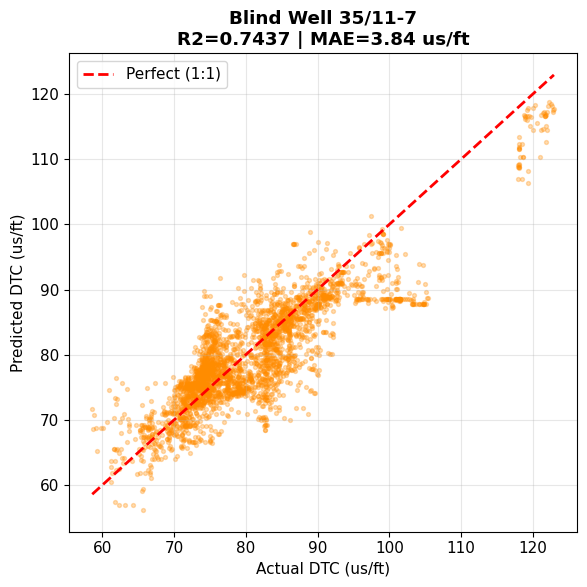

In [190]:
# ── Scatter: Actual vs Predicted on blind well ────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_blind, y_blind_pred, alpha=0.3, s=8, color='darkorange')
mn, mx = y_blind.min(), y_blind.max()
ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect (1:1)')
ax.set_xlabel('Actual DTC (us/ft)')
ax.set_ylabel('Predicted DTC (us/ft)')
ax.set_title(f'Blind Well 35/11-7\nR2={r2_b:.4f} | MAE={mae_b:.2f} us/ft',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


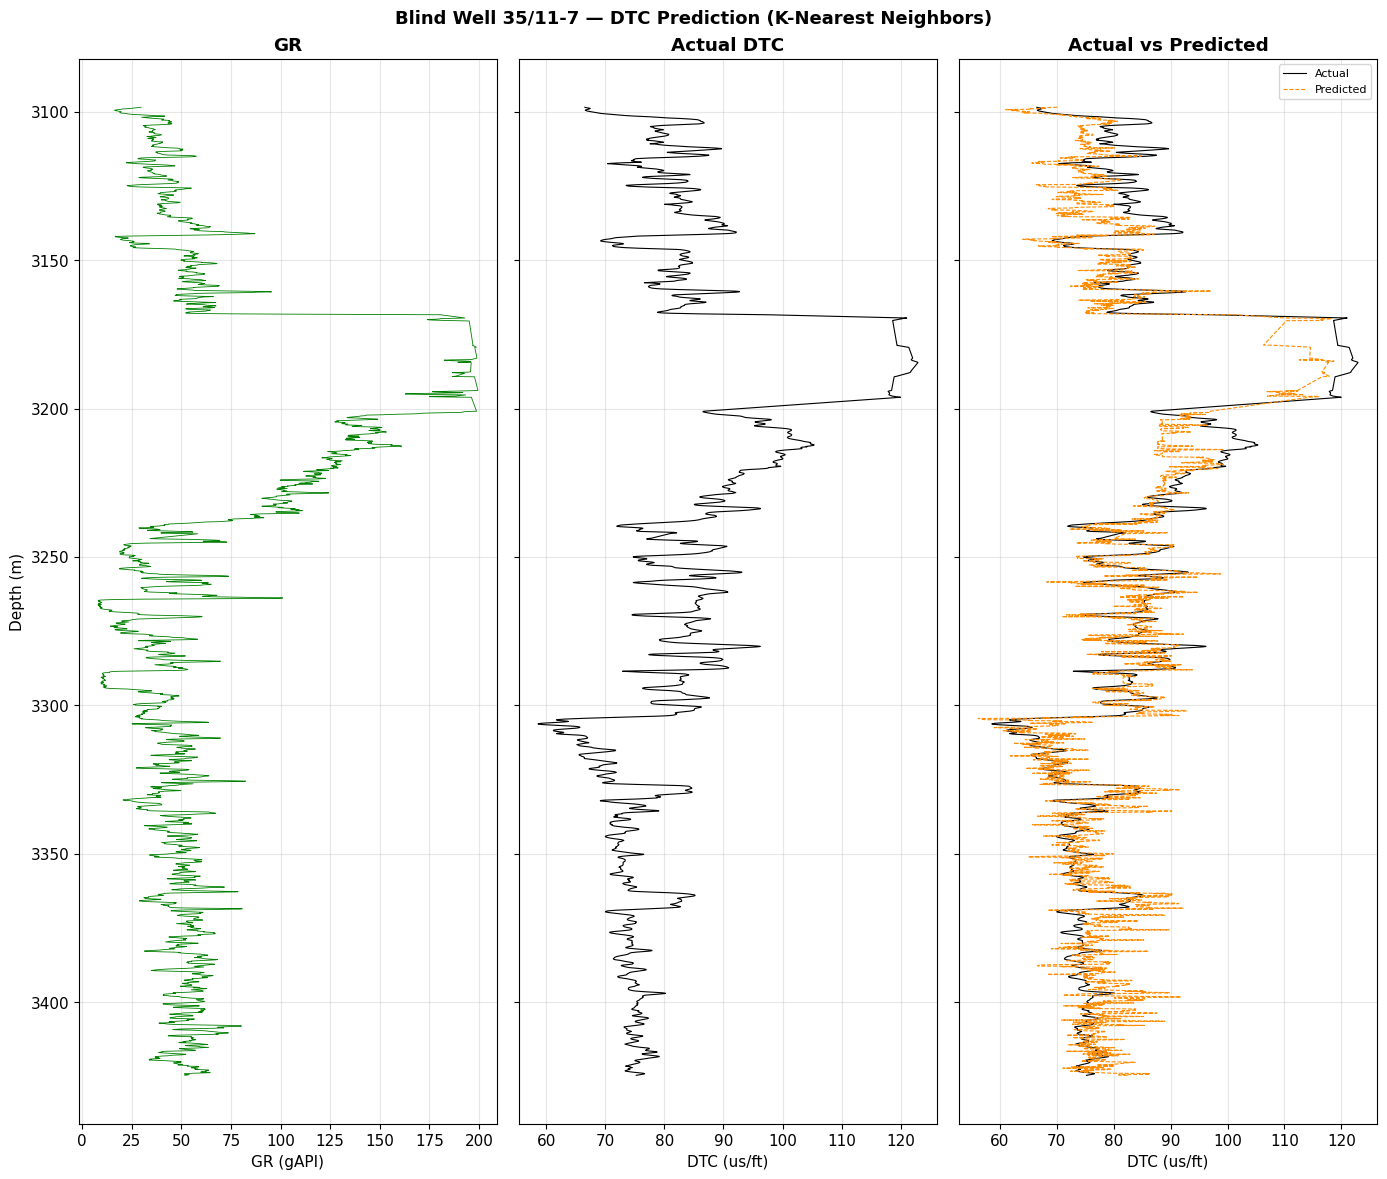

In [191]:
# ── Log track: Actual vs Predicted vs Depth ──────────────────────────────
depth_blind = df_blind['DEPTH'].values

fig, axes = plt.subplots(1, 3, figsize=(14, 12), sharey=True)
fig.suptitle(f'Blind Well 35/11-7 — DTC Prediction ({best_model_name})',
             fontsize=13, fontweight='bold')

axes[0].plot(df_blind['GR'].values, depth_blind, 'green', lw=0.6)
axes[0].set_xlabel('GR (gAPI)'); axes[0].set_title('GR', fontweight='bold')
axes[0].set_ylabel('Depth (m)'); axes[0].invert_yaxis(); axes[0].grid(True, alpha=0.3)

axes[1].plot(y_blind, depth_blind, 'black', lw=0.8, label='Actual')
axes[1].set_xlabel('DTC (us/ft)'); axes[1].set_title('Actual DTC', fontweight='bold')
axes[1].invert_yaxis(); axes[1].grid(True, alpha=0.3)

axes[2].plot(y_blind,      depth_blind, 'black',      lw=0.8, label='Actual')
axes[2].plot(y_blind_pred, depth_blind, 'darkorange',  lw=0.8, ls='--', label='Predicted')
axes[2].set_xlabel('DTC (us/ft)'); axes[2].set_title('Actual vs Predicted', fontweight='bold')
axes[2].legend(fontsize=8); axes[2].invert_yaxis(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 📊 STEP 12 — Final Summary


In [193]:
# ── Print complete summary ────────────────────────────────────────────────
print('=' * 60)
print('          SESSION SUMMARY')
print('=' * 60)
print(f'  Training wells : 35/11-1, 35/11-5, 35/11-6')
print(f'  Blind well     : 35/11-7')
print(f'  Target log     : DTC')
print(f'  Features       : {FEATURES}')
print(f'  Training rows  : {len(X_all):,}')
print(f'  Blind rows     : {len(X_blind_scaled):,}')
print('\n  ALL MODELS RANKED:')
display(results_df)
print(f'\n  BEST MODEL ON BLIND WELL:')
print(f'  Model : {best_model_name}')
print(f'  R2    : {r2_b:.4f}')
print(f'  MAE   : {mae_b:.2f} us/ft')
print(f'  RMSE  : {rmse_b:.2f} us/ft')
print('=' * 60)


          SESSION SUMMARY
  Training wells : 35/11-1, 35/11-5, 35/11-6
  Blind well     : 35/11-7
  Target log     : DTC
  Features       : ['RHOB', 'GR', 'NPHI', 'PEF']
  Training rows  : 20,840
  Blind rows     : 2,982

  ALL MODELS RANKED:


,Model,R2,MAE,RMSE
1,K-Nearest Neighbors,0.9531,1.507,2.765
2,Random Forest,0.9502,1.577,2.849
3,xgboost,0.9453,1.772,2.985
4,Neural Network,0.9306,2.122,3.362
5,Linear Regression,0.9040,2.780,3.954
6,Ridge,0.9040,2.780,3.954
7,Decision Tree,0.9030,1.995,3.975
8,Lasso,0.8943,3.051,4.150



  BEST MODEL ON BLIND WELL:
  Model : K-Nearest Neighbors
  R2    : 0.7437
  MAE   : 3.84 us/ft
  RMSE  : 5.07 us/ft


---
## Key Takeaways
| Concept | What we learned |
|---------|----------------|
| Csv files | loading to dataframe; null=-999.25 → replace with NaN |
| Data cleaning | Drop NaN + physical range filters before modeling |
| Histograms | Value distributions — detect skewness and outliers |
| Boxplots | Compare wells — dots outside whiskers = outliers |
| Correlation | High correlation with DTC = good predictor |
| Pairplot | All log relationships at once |
| Scaling | Fit on train only — never on blind well |
| Blind well | Final unbiased test — never trained on it |
| R2 | Proportion of variance explained (1.0 = perfect) |
| MAE | Average error in original units (us/ft) |
| Feature Importance | Which log drives the prediction most |
| Residuals | Error = Actual - Predicted — should center at 0 |
